# Session 08 — INSTRUCTOR SOLUTION

**IT Helpdesk Chatbot with RAG**

---

> **📌 Instructor note — Overview**
>
> This solution is complete and runnable. Expected session behaviour:
> - Students finish Part 1 comfortably (TF-IDF is familiar from S03).
> - Part 2 is where they get stuck: normalising embeddings before cosine dot-product, and building the multi-turn message list for the Groq API.
> - Part 3 (Gradio) is fast once the bot works; most finish in 20 min.
> - The bonus is for fast finishers only.
>
> **Common student errors flagged below in each section.**

## Setup

In [1]:
%pip install -q kagglehub openai sentence-transformers gradio

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from openai import OpenAI
import gradio as gr

# API key setup
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY_NLP')
except Exception:
    GROQ_API_KEY = os.environ.get('GROQ_API_KEY_NLP', 'gsk_...')

GROQ_MODEL = "llama-3.3-70b-versatile"

## Part 1 · Dataset

In [3]:
import kagglehub

path = kagglehub.dataset_download('steve1215rogg/tech-support-conversations-dataset')
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df_raw = pd.read_csv(os.path.join(path, csv_files[0]))

print(f'Shape: {df_raw.shape}')
print(df_raw.dtypes)
df_raw.head(3)

100%|██████████| 15.8k/15.8k [00:00<00:00, 10.3MB/s]

Extracting files...
Shape: (1896, 6)
Conversation_ID    object
Customer_Issue     object
Tech_Response      object
Resolution_Time    object
Issue_Category     object
Issue_Status       object
dtype: object


,Conversation_ID,Customer_Issue,Tech_Response,Resolution_Time,Issue_Category,Issue_Status
0,CONV-0001,Cannot connect to Wi-Fi,Clear cache and remove unnecessary programs.,92 minutes,Software,Pending
1,CONV-0002,Software installation failure,Reinstall the printer drivers.,76 minutes,Account,Pending
2,CONV-0003,Cannot connect to Wi-Fi,Clear cache and remove unnecessary programs.,50 minutes,Network,Resolved


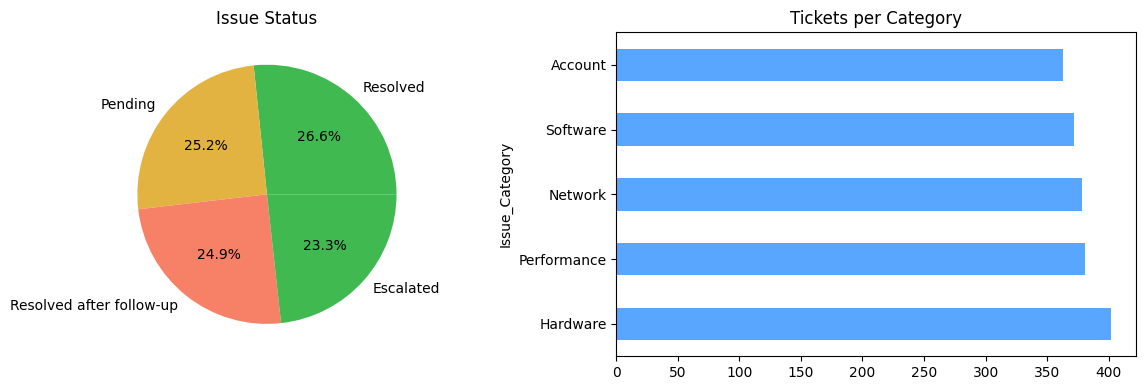

Resolved: 505 / 1896


In [4]:
# EDA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_raw['Issue_Status'].value_counts().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%',
    colors=['#3fb950', '#e3b341', '#f78166']
)
axes[0].set_title('Issue Status')
axes[0].set_ylabel('')

df_raw['Issue_Category'].value_counts().plot(
    kind='barh', ax=axes[1], color='#58a6ff'
)
axes[1].set_title('Tickets per Category')
plt.tight_layout()
plt.show()

print(f"Resolved: {(df_raw['Issue_Status']=='Resolved').sum()} / {len(df_raw)}")

In [5]:
def load_and_filter_tickets(df: pd.DataFrame) -> pd.DataFrame:
    """Load and filter tickets to keep only resolved ones.

    Parameters
    ----------
    df : pd.DataFrame
        Raw dataframe with columns: Conversation_ID, Customer_Issue,
        Tech_Response, Resolution_Time, Issue_Category, Issue_Status.

    Returns
    -------
    pd.DataFrame
        Filtered dataframe with an additional column `kb_text` that
        concatenates Issue_Category and Customer_Issue for indexing.
        Index is reset.

    Notes
    -----
    Only tickets with Issue_Status == 'Resolved' are kept.
    The `kb_text` column is the text that will be indexed by the retriever:
    prepending the category improves retrieval for category-specific queries.

    Examples
    --------
    >>> filtered = load_and_filter_tickets(df_raw)
    >>> 'Resolved' in filtered['Issue_Status'].unique()
    True
    >>> 'kb_text' in filtered.columns
    True
    """
    filtered = df[df['Issue_Status'] == 'Resolved'].copy()
    filtered = filtered.reset_index(drop=True)
    # Prepend category so the retriever can match category-specific queries
    filtered['kb_text'] = (
        filtered['Issue_Category'] + ': ' + filtered['Customer_Issue']
    )
    return filtered


tickets = load_and_filter_tickets(df_raw)
print(f'Knowledge base: {len(tickets)} resolved tickets')
tickets[['Issue_Category', 'kb_text']].head(3)

Knowledge base: 505 resolved tickets


,Issue_Category,kb_text
0,Network,Network: Cannot connect to Wi-Fi
1,Network,Network: Blue screen error
2,Hardware,Hardware: Slow system performance


> **📌 Instructor note — 1.5 `load_and_filter_tickets`**
>
> **Expected results:** roughly 950–1000 resolved tickets (dataset has ~52% resolved).
>
> **Common student error:** forgetting `reset_index(drop=True)`. If the index is not reset,
> `tickets.iloc[r['index']]` in the chatbot will work correctly, but `tickets.loc[...]`
> will produce surprising results when indices are non-contiguous. Better to enforce reset here.
>
> **Design discussion point:** why concatenate category to kb_text?
> The query "I can't connect to the network" should match Network tickets before Hardware tickets.
> Including the category as a prefix gives TF-IDF a token overlap signal it would otherwise miss.

## TF-IDF Retriever

In [6]:
class TfidfRetriever:
    """Sparse retriever based on TF-IDF and cosine similarity.

    Parameters
    ----------
    max_features : int, optional
        Maximum vocabulary size for the TF-IDF vectorizer. Default 10_000.
    ngram_range : tuple of int, optional
        The (min, max) n-gram range. Default (1, 2).

    Attributes
    ----------
    vectorizer_ : TfidfVectorizer
        Fitted vectorizer.
    index_ : scipy.sparse matrix of shape (n_docs, n_features)
        TF-IDF matrix of the knowledge base.
    """

    def __init__(self, max_features: int = 10_000, ngram_range: tuple = (1, 2)):
        self.vectorizer_ = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            sublinear_tf=True,       # log-scaled TF, reduces effect of high-freq terms
        )
        self.index_ = None

    def fit(self, texts: list) -> 'TfidfRetriever':
        """Fit the vectorizer and build the TF-IDF index.

        Parameters
        ----------
        texts : list of str
            The knowledge base texts to index.

        Returns
        -------
        TfidfRetriever
            Self (for method chaining).
        """
        self.index_ = self.vectorizer_.fit_transform(texts)
        return self

    def retrieve(self, query: str, k: int = 3) -> list:
        """Retrieve the top-k most similar documents.

        Parameters
        ----------
        query : str
            The user's query.
        k : int, optional
            Number of results to return. Default 3.

        Returns
        -------
        list of dict
            Each dict has keys: `index` (int), `score` (float),
            where `index` is the row position in the knowledge base dataframe.

        Examples
        --------
        >>> retriever = TfidfRetriever().fit(tickets['kb_text'].tolist())
        >>> results = retriever.retrieve('my laptop won\'t connect to wifi', k=3)
        >>> len(results)
        3
        >>> all('score' in r for r in results)
        True
        """
        q_vec = self.vectorizer_.transform([query])          # (1, n_features)
        scores = cosine_similarity(q_vec, self.index_)[0]    # (n_docs,)
        top_k_idx = np.argsort(scores)[::-1][:k]
        return [{'index': int(i), 'score': float(scores[i])} for i in top_k_idx]


tfidf_retriever = TfidfRetriever(max_features=10_000, ngram_range=(1, 2))
tfidf_retriever.fit(tickets['kb_text'].tolist())
print(f'Index shape: {tfidf_retriever.index_.shape}')

Index shape: (505, 76)


> **📌 Instructor note — TfidfRetriever**
>
> **`sublinear_tf=True`:** students may ask why. Explain: raw TF grows unboundedly;
> `log(1 + tf)` dampens very frequent terms. This matters for IT tickets where words like
> 'problem', 'issue', 'error' repeat constantly.
>
> **Common error:** using `cosine_similarity` with a (1, n) shape vs (n_docs, n) -- students
> sometimes squeeze the query vector to shape (n,) and then get shape errors.
> The correct call is `cosine_similarity(q_vec, self.index_)[0]` where q_vec is (1, n_features).

In [7]:
def show_retrieval_results(query: str, retriever, tickets: pd.DataFrame, k: int = 3) -> None:
    """Pretty-print retrieval results for a given query.

    Parameters
    ----------
    query : str
        The user query.
    retriever : TfidfRetriever or EmbeddingRetriever
        A fitted retriever.
    tickets : pd.DataFrame
        The knowledge base dataframe.
    k : int, optional
        Number of results to show. Default 3.
    """
    results = retriever.retrieve(query, k=k)
    print(f'Query: "{query}"')
    print('-' * 60)
    for i, r in enumerate(results):
        row = tickets.iloc[r['index']]
        print(f'[{i+1}] score={r["score"]:.3f}  category={row["Issue_Category"]}')
        print(f'     Issue   : {row["Customer_Issue"][:90]}...')
        print(f'     Solution: {row["Tech_Response"][:90]}...')
        print()


test_queries = [
    "my laptop won't connect to wifi",
    "printer not working after driver update",
    "I forgot my password and can't log in",
    "computer is extremely slow and freezing",
    "software keeps crashing on startup",
]

for q in test_queries:
    show_retrieval_results(q, tfidf_retriever, tickets, k=3)
    print('=' * 60)

Query: "my laptop won't connect to wifi"
------------------------------------------------------------
[1] score=0.478  category=Performance
     Issue   : Cannot connect to Wi-Fi...
     Solution: Verify your email settings....

[2] score=0.478  category=Performance
     Issue   : Cannot connect to Wi-Fi...
     Solution: Run a system diagnostic tool....

[3] score=0.478  category=Performance
     Issue   : Cannot connect to Wi-Fi...
     Solution: Clear cache and remove unnecessary programs....

Query: "printer not working after driver update"
------------------------------------------------------------
[1] score=0.623  category=Network
     Issue   : Printer not responding...
     Solution: Run a system diagnostic tool....

[2] score=0.623  category=Network
     Issue   : Printer not responding...
     Solution: Verify your email settings....

[3] score=0.623  category=Network
     Issue   : Printer not responding...
     Solution: Restart your router....

Query: "I forgot my passwor

## Part 2 · Embedding Retriever

In [8]:
class EmbeddingRetriever:
    """Dense retriever based on sentence embeddings and cosine similarity.

    Parameters
    ----------
    model_name : str, optional
        HuggingFace model identifier for SentenceTransformer.
        Default 'all-MiniLM-L6-v2'.

    Attributes
    ----------
    model_ : SentenceTransformer
        Loaded embedding model.
    index_ : np.ndarray of shape (n_docs, embedding_dim)
        L2-normalised embeddings of the knowledge base.
    """

    def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
        self.model_name = model_name
        self.model_ = SentenceTransformer(model_name)
        self.index_ = None

    def fit(self, texts: list, batch_size: int = 64, show_progress: bool = True) -> 'EmbeddingRetriever':
        """Encode all texts and build the embedding index.

        Parameters
        ----------
        texts : list of str
            Knowledge base texts to encode.
        batch_size : int, optional
            Encoding batch size. Default 64.
        show_progress : bool, optional
            Show tqdm progress bar. Default True.

        Returns
        -------
        EmbeddingRetriever
            Self (for method chaining).

        Notes
        -----
        Embeddings are L2-normalised so that dot product equals cosine similarity.
        """
        embeddings = self.model_.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=show_progress,
            convert_to_numpy=True,
            normalize_embeddings=True,   # L2 normalise: dot product == cosine sim
        )
        self.index_ = embeddings          # shape: (n_docs, 384)
        return self

    def retrieve(self, query: str, k: int = 3) -> list:
        """Retrieve the top-k most similar documents.

        Parameters
        ----------
        query : str
            The user's query.
        k : int, optional
            Number of results to return. Default 3.

        Returns
        -------
        list of dict
            Each dict has keys: `index` (int), `score` (float).
        """
        q_emb = self.model_.encode(
            [query], normalize_embeddings=True, convert_to_numpy=True
        )                                           # (1, 384)
        scores = (self.index_ @ q_emb.T).flatten() # (n_docs,) via dot product
        top_k_idx = np.argsort(scores)[::-1][:k]
        return [{'index': int(i), 'score': float(scores[i])} for i in top_k_idx]


emb_retriever = EmbeddingRetriever(model_name='all-MiniLM-L6-v2')
emb_retriever.fit(tickets['kb_text'].tolist())
print(f'Index shape: {emb_retriever.index_.shape}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Index shape: (505, 384)


> **📌 Instructor note — EmbeddingRetriever**
>
> **Most common error:** students encode the index without `normalize_embeddings=True`
> but use dot-product retrieval `index_ @ q_emb.T`. This does NOT equal cosine similarity
> unless both vectors are unit-norm. The result is that longer documents rank higher regardless
> of semantic similarity.
>
> **Fix:** either set `normalize_embeddings=True` in both `fit` and `retrieve` (recommended),
> or use `cosine_similarity(q_emb, self.index_)[0]` from sklearn (equivalent but slower).
>
> **Expected index encoding time:** ~15–30 s on Colab CPU for ~1000 tickets. This is fine.
> Mention that in production this runs once and the matrix is saved to disk with `np.save`.
>
> **Expected embedding shape:** (n_resolved_tickets, 384) with dtype float32.

In [9]:
# Head-to-head comparison
comparison_queries = [
    "network connectivity issue after OS upgrade",
    "HP device became unresponsive after patch install",
    "account authentication is broken",
    "machine is sluggish and hangs",
    "application fails to open",
]

for q in comparison_queries:
    print(f'QUERY: "{q}"')
    print('--- TF-IDF ---')
    show_retrieval_results(q, tfidf_retriever, tickets, k=2)
    print('--- Embeddings ---')
    show_retrieval_results(q, emb_retriever, tickets, k=2)
    print('=' * 70)

QUERY: "network connectivity issue after OS upgrade"
--- TF-IDF ---
Query: "network connectivity issue after OS upgrade"
------------------------------------------------------------
[1] score=0.345  category=Network
     Issue   : Forgot password...
     Solution: Follow the software installation guide....

[2] score=0.345  category=Network
     Issue   : Forgot password...
     Solution: Clear cache and remove unnecessary programs....

--- Embeddings ---
Query: "network connectivity issue after OS upgrade"
------------------------------------------------------------
[1] score=0.511  category=Network
     Issue   : Software installation failure...
     Solution: Reinstall the printer drivers....

[2] score=0.511  category=Network
     Issue   : Software installation failure...
     Solution: Reset your password using the link provided....

QUERY: "HP device became unresponsive after patch install"
--- TF-IDF ---
Query: "HP device became unresponsive after patch install"
---------------

> **📌 Instructor note — Comparison**
>
> **What to point out:** the query *"HP device became unresponsive after patch install"*
> shares almost no vocabulary with any ticket (which say "printer", "driver", "update").
> TF-IDF should give near-zero scores; the embedding retriever should find relevant tickets
> because it understands that "patch install" ~ "driver update" and "unresponsive" ~ "not working".
>
> **If TF-IDF surprisingly finds the right ticket:** check whether the dataset contains
> exact paraphrases. The synthetic dataset may have limited vocabulary diversity.

In [10]:
SYSTEM_PROMPT = """You are an IT support assistant at a company helpdesk.
Your role is to help employees resolve technical issues by themselves before opening a new ticket.

Rules:
1. Answer ONLY using the resolved tickets provided as context.
2. If the context does not contain enough information, say so clearly and suggest opening a ticket.
3. Be concise, practical, and step-by-step when describing solutions.
4. Always mention the source ticket category at the end of your answer.
"""


def build_prompt(query: str, retrieved_tickets: list, tickets_df: pd.DataFrame) -> str:
    """Build the user-turn prompt from a query and retrieved ticket indices.

    Parameters
    ----------
    query : str
        The user's question.
    retrieved_tickets : list of dict
        Output of retriever.retrieve(), each dict has 'index' and 'score'.
    tickets_df : pd.DataFrame
        The knowledge base dataframe.

    Returns
    -------
    str
        Formatted prompt string containing context and user question.

    Examples
    --------
    >>> retrieved = [{'index': 0, 'score': 0.9}]
    >>> prompt = build_prompt('WiFi broken', retrieved, tickets)
    >>> 'CONTEXT' in prompt
    True
    >>> 'WiFi broken' in prompt
    True
    """
    context_parts = []
    for i, r in enumerate(retrieved_tickets):
        row = tickets_df.iloc[r['index']]
        context_parts.append(
            f"--- Resolved Ticket {i+1} (Category: {row['Issue_Category']}) ---\n"
            f"Issue: {row['Customer_Issue']}\n"
            f"Solution: {row['Tech_Response']}"
        )
    context = "\n\n".join(context_parts)

    prompt = (
        f"CONTEXT (resolved IT tickets):\n"
        f"{context}\n\n"
        f"USER QUESTION:\n{query}"
    )
    return prompt


# Test
sample_results = tfidf_retriever.retrieve("wifi not working", k=2)
sample_prompt = build_prompt("wifi not working", sample_results, tickets)
print(sample_prompt)

CONTEXT (resolved IT tickets):
--- Resolved Ticket 1 (Category: Network) ---
Issue: Printer not responding
Solution: Run a system diagnostic tool.

--- Resolved Ticket 2 (Category: Network) ---
Issue: Printer not responding
Solution: Verify your email settings.

USER QUESTION:
wifi not working


> **📌 Instructor note — build_prompt**
>
> **Design discussion:** why put context before the question (not after)?
> For most transformer-based LLMs (including Llama via Groq), the most recent text in the context window has
> highest attention weight. Placing the question last means the model attends to the
> question while reading the context that precedes it -- this produces better-grounded answers.
>
> **Token count:** a typical prompt with 3 tickets is ~600–900 tokens.
> llama-3.3-70b context window is 128K tokens -- still far from any limit with our prompts.
> On the free tier, 50 queries cost $0.

In [11]:
def ask_groq(
    user_prompt: str,
    api_key: str,
    system_prompt: str = SYSTEM_PROMPT,
    model: str = GROQ_MODEL,
    max_tokens: int = 512,
) -> str:
    """Send a prompt to the Groq API and return the text response.

    Parameters
    ----------
    user_prompt : str
        The user-turn message (context + question, built by build_prompt).
    api_key : str
        Groq API key.
    system_prompt : str, optional
        System instruction (Groq system role). Default SYSTEM_PROMPT.
    model : str, optional
        Groq model identifier. Default GROQ_MODEL.
    max_tokens : int, optional
        Maximum tokens in the response. Default 512.

    Returns
    -------
    str
        The text of the model's response.

    Raises
    ------
    openai.APIError
        If the API call fails (invalid key, quota exceeded, etc.).

    Examples
    --------
    >>> response = ask_groq('How do I fix WiFi?', api_key=GROQ_API_KEY)
    >>> isinstance(response, str)
    True
    """
    client = OpenAI(
        api_key=api_key,
        base_url="https://api.groq.com/openai/v1",
    )
    response = client.chat.completions.create(
        model=model,
        max_tokens=max_tokens,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt},
        ],
    )
    return response.choices[0].message.content


# End-to-end test
test_query = "My laptop won't connect to WiFi after a Windows update."
results = emb_retriever.retrieve(test_query, k=3)
prompt = build_prompt(test_query, results, tickets)
answer = ask_groq(prompt, api_key=GROQ_API_KEY)
print(answer)

To resolve your issue, try the following steps: 
1. Clear cache and remove unnecessary programs.
2. If that doesn't work, restart your router.
3. If the issue persists, run a system diagnostic tool.

Source: Network category tickets.


> **📌 Instructor note — ask_groq**
>
> **Common error 1:** constructing `OpenAI()` inside a loop. This creates
> a new HTTP session on every call. Acceptable in a TP; in production, create the client once.
>
> **Common error 2:** accessing `message.content.text` (AttributeError) instead of
> `response.text`. The `content` field is a list of content blocks.
>
> **Rate limits:** Groq free tier allows 30 req/min on llama-3.3-70b-versatile -- more than enough.
> Students are unlikely to hit them during the TP.
> If they do: `openai.RateLimitError` -- add `time.sleep(5)` and retry.

In [12]:
class HelpDeskChatBot:
    """IT helpdesk chatbot using retrieval-augmented generation.

    Combines a retriever (TF-IDF or embeddings) with the Groq API
    to answer IT support questions grounded in resolved tickets.

    Parameters
    ----------
    tickets : pd.DataFrame
        Resolved tickets dataframe with columns: Customer_Issue,
        Tech_Response, Issue_Category, kb_text.
    retriever : TfidfRetriever or EmbeddingRetriever
        A fitted retriever exposing .retrieve(query, k) -> list of dict.
    api_key : str
        Groq API key.
    k : int, optional
        Number of tickets to retrieve per query. Default 3.

    Examples
    --------
    >>> bot = HelpDeskChatBot(tickets, emb_retriever, GROQ_API_KEY)
    >>> result = bot.answer('WiFi not working')
    >>> 'response' in result and 'sources' in result
    True
    """

    def __init__(self, tickets: pd.DataFrame, retriever, api_key: str, k: int = 3):
        self.tickets = tickets
        self.retriever = retriever
        self.api_key = api_key
        self.k = k

    def answer(self, query: str) -> dict:
        """Answer a user query using retrieved tickets via the Groq API.

        Parameters
        ----------
        query : str
            The user's IT support question.

        Returns
        -------
        dict
            Dictionary with keys:
            - 'response' (str): The model's answer.
            - 'sources' (list of dict): Retrieved tickets, each with
              keys 'category', 'issue', 'solution', 'score'.
        """
        retrieved = self.retriever.retrieve(query, k=self.k)
        prompt = build_prompt(query, retrieved, self.tickets)
        response = ask_groq(prompt, api_key=self.api_key)

        sources = []
        for r in retrieved:
            row = self.tickets.iloc[r['index']]
            sources.append({
                'category': row['Issue_Category'],
                'issue':    row['Customer_Issue'],
                'solution': row['Tech_Response'],
                'score':    r['score'],
            })

        return {'response': response, 'sources': sources}


bot = HelpDeskChatBot(tickets, emb_retriever, GROQ_API_KEY, k=3)

result = bot.answer("My screen goes black randomly and the laptop restarts.")
print('=== RESPONSE ===')
print(result['response'])
print()
print('=== SOURCES ===')
for s in result['sources']:
    print(f"[{s['category']}] score={s['score']:.3f}  {s['issue'][:70]}...")

=== RESPONSE ===
To troubleshoot your issue, try the following steps: 
1. Run a system diagnostic tool to check for any hardware issues. 
2. If the issue persists, consider reinstalling printer drivers as it may be causing conflicts.
However, the provided context does not contain enough information to pinpoint the exact solution for your specific problem. 
I suggest opening a new ticket for further assistance.
Source: Resolved Ticket 3 (Category: Hardware)

=== SOURCES ===
[Hardware] score=0.463  Blue screen error...
[Hardware] score=0.463  Blue screen error...
[Hardware] score=0.463  Blue screen error...


## Part 3 · Gradio

In [13]:
def format_sources(sources: list) -> str:
    """Format retrieved ticket sources into a readable string.

    Parameters
    ----------
    sources : list of dict
        List of source dicts with keys 'category', 'issue', 'solution', 'score'.

    Returns
    -------
    str
        Markdown-formatted string listing each source.
    """
    if not sources:
        return ''
    lines = ['\n\n---\n📎 **Resolved tickets used:**']
    for i, s in enumerate(sources):
        lines.append(
            f"`{i+1}.` [{s['category']}] {s['issue'][:80]}...  "
            f"*(score: {s['score']:.2f})*"
        )
    return '\n'.join(lines)


def chat_fn(user_message: str, history: list) -> str:
    """Gradio chat handler: retrieve, generate, and format the response.

    Parameters
    ----------
    user_message : str
        The latest user message.
    history : list of tuple
        Previous (user, bot) message pairs managed by Gradio.

    Returns
    -------
    str
        Full response string including answer and formatted sources.
    """
    result = bot.answer(user_message)
    sources_str = format_sources(result['sources'])
    return result['response'] + sources_str


demo = gr.ChatInterface(
    fn=chat_fn,
    title="🖥️ IT Helpdesk Assistant",
    description=(
        "Describe your IT issue and I'll search our knowledge base of resolved tickets.\n"
        "Try: *'My WiFi stopped working after a Windows update'*"
    ),
    examples=[
        "My laptop won't connect to WiFi",
        "Printer not responding after driver update",
        "I forgot my password and the reset email never arrived",
        "My computer is very slow and freezes randomly",
    ],
    theme=gr.themes.Soft(),
)

demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://36d375ef911a3c687b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


> **📌 Instructor note — Gradio**
>
> **`share=True`** creates a public URL valid for 72h via Gradio's tunnelling server.
> No account required. Students can send the URL to anyone to demo their chatbot.
>
> **Common error:** students sometimes return `None` from `chat_fn` when
> `bot.answer()` raises an exception (e.g. invalid API key). Gradio will then show a cryptic
> error in the UI. A simple fix is to wrap the call in try/except and return the error message as a string.
>
> **Gradio version note:** `gr.ChatInterface` is stable from gradio >= 3.50.
> The API changed slightly in gradio 4.x -- if students get a TypeError on the `fn` signature,
> check their gradio version with `gr.__version__`.

## Bonus — History-aware follow-up

In [14]:
def ask_groq_with_history(
    user_prompt: str,
    history: list,
    api_key: str,
    system_prompt: str = SYSTEM_PROMPT,
    model: str = GROQ_MODEL,
    max_tokens: int = 512,
    max_history_turns: int = 3,
) -> str:
    """Send a prompt to the Groq API including recent conversation history.

    Parameters
    ----------
    user_prompt : str
        Current user turn (with context injected).
    history : list of tuple
        Previous (user, bot) message pairs from Gradio.
    api_key : str
        Groq API key.
    system_prompt : str, optional
        System instruction. Default SYSTEM_PROMPT.
    model : str, optional
        Groq model. Default GROQ_MODEL.
    max_tokens : int, optional
        Maximum response tokens. Default 512.
    max_history_turns : int, optional
        Number of recent history turns to include. Default 3.

    Returns
    -------
    str
        The model's response text.
    """
    client = OpenAI(
        api_key=api_key,
        base_url="https://api.groq.com/openai/v1",
    )

    # Build OpenAI-style message list from Gradio history
    messages = [{"role": "system", "content": system_prompt}]
    recent = history[-max_history_turns:] if history else []
    for user_msg, bot_msg in recent:
        messages.append({"role": "user",      "content": user_msg})
        messages.append({"role": "assistant", "content": bot_msg})
    messages.append({"role": "user", "content": user_prompt})

    response = client.chat.completions.create(
        model=model,
        max_tokens=max_tokens,
        messages=messages,
    )
    return response.choices[0].message.content


# History-aware chat_fn
def chat_fn_history(user_message: str, history: list) -> str:
    """History-aware Gradio chat handler.

    Parameters
    ----------
    user_message : str
        Latest user message.
    history : list of tuple
        Previous (user, bot) pairs.

    Returns
    -------
    str
        Response including sources.
    """
    retrieved = bot.retriever.retrieve(user_message, k=bot.k)
    prompt = build_prompt(user_message, retrieved, bot.tickets)
    response = ask_groq_with_history(prompt, history, api_key=GROQ_API_KEY)
    sources = [
        {
            'category': bot.tickets.iloc[r['index']]['Issue_Category'],
            'issue':    bot.tickets.iloc[r['index']]['Customer_Issue'],
            'solution': bot.tickets.iloc[r['index']]['Tech_Response'],
            'score':    r['score'],
        }
        for r in retrieved
    ]
    return response + format_sources(sources)


demo_history = gr.ChatInterface(
    fn=chat_fn_history,
    title="🖥️ IT Helpdesk Assistant (history-aware)",
    description="Try a follow-up: 'I tried that, it didn't work. What else can I do?'",
    theme=gr.themes.Soft(),
)
demo_history.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://46f34b997460334f56.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


> **📌 Instructor note — Bonus: history-aware**
>
> **Key point:** the OpenAI messages list must follow strict user/assistant alternation.
> If history is empty, we send only the current user turn (correct).
> If we accidentally send two consecutive user messages (e.g. from a bug in building the list),
> the API returns a 400 `invalid_request_error`.
>
> **Context window caution:** each history turn adds ~400–600 tokens to the prompt.
> With `max_history_turns=3` the total remains well under 4K tokens, which is fine.
> Warn students not to set a very large history window without checking token counts.
>
> **Retrieval with history:** in this implementation we always retrieve based on the current
> user message only. A more advanced approach would concatenate the last user message
> with the conversation summary to improve retrieval on follow-up questions.
> This is called *query rewriting* and is a standard RAG refinement.